# Ts 包 CCF 使用指南：可执行 Notebook

本 Notebook 将直接运行 Ts 包当前的 CCF 功能，并保留代码、表格和图形输出。

CCF 在 Ts 中主要用于传递函数/RDL 模型的残差诊断：它检验最终输出残差与输入 ARIMA 预白化模型新息之间是否还存在系统性动态关系。

## Goal

完成本 Notebook 后，你应能：

1. 用 `ResidualCCFTest` 计算逐阶残差 CCF 和联合 `S*` 检验；
2. 读取显著滞后、置信带和多输入检验表；
3. 使用统一的 `plot_test()`/`plot_correlogram()` 绘图；
4. 对已拟合的 RDL/SARIMAX 模型运行 `residual_ccf_test()`；
5. 识别输入预白化、样本对齐和模型规格错误。

## Setup

本 Notebook 使用固定随机种子生成可重复的教学数据，不读取外部文件。正滞后 `k` 的定义是：当前输出残差 `a_t` 与过去 `k` 期输入新息 `e_{t-k}` 的相关。

In [1]:
from pathlib import Path
import io
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

# 让 Notebook 从仓库根目录或 docs 目录执行时都能导入本地 Ts 包。
repo_root = Path.cwd()
if not (repo_root / "TsTests").exists():
    repo_root = (repo_root / "..").resolve()
sys.path.insert(0, str(repo_root))

from Ts.TsModels import RationalLagSpec, SARIMAX
from Ts.TsPlots import plot_correlogram
from Ts.TsTests import ResidualCCFTest

pd.set_option("display.float_format", lambda value: f"{value:.4f}")

def show_figure(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
    buffer.close()
print(f"Repository: {repo_root}")
print(f"NumPy: {np.__version__}")

Repository: C:\Users\NIU\Desktop\Ts
NumPy: 2.5.1


## 1. Direct residual CCF

先构造一个已知动态：输出残差主要由输入新息向后移动 2 期得到。这样 `lag=2` 应出现明显的正 CCF 峰值。

In [2]:
rng = np.random.default_rng(2413)
input_innovations = rng.normal(size=240)
output_residuals = np.roll(input_innovations, 2)
output_residuals += rng.normal(scale=0.08, size=240)
output_residuals[:2] = rng.normal(size=2)

direct_result = ResidualCCFTest(
    output_residuals,
    pd.Series(input_innovations, name="shock"),
    lags=6,
).fit()
direct_item = direct_result.get("shock")

print("Input names:", direct_result.input_names)
print("Effective observations:", direct_item.nobs)
print("Significant lags:", direct_item.significant_lags)
display(direct_result.tests.round(4))
display(direct_item.correlations.rename("ccf").to_frame().round(4))

Input names: ('shock',)
Effective observations: 240
Significant lags: (2,)


,input,s_statistic,df,p_value,reject,nobs,transfer_params
0,shock,244.6162,7,0.0000,True,240,0


,ccf
lag,
0,-0.0455
1,-0.0618
2,0.9951
3,-0.0617
4,-0.0464
5,0.0110
6,-0.0914


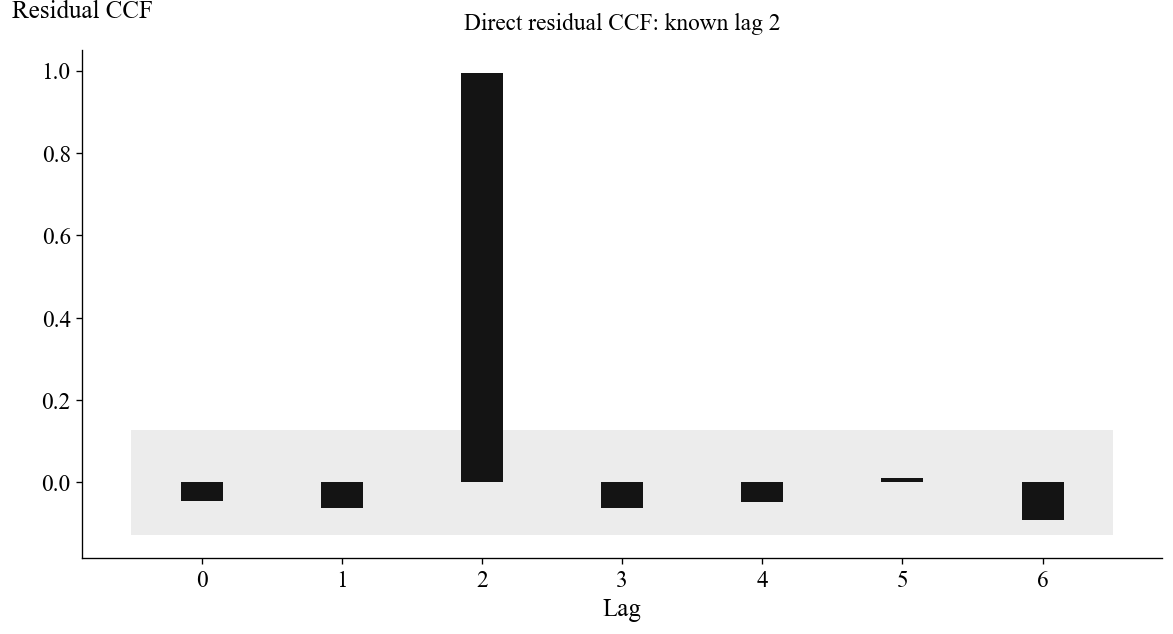

In [3]:
fig, ax = direct_item.plot_test(title="Direct residual CCF: known lag 2")
show_figure(fig)
plt.close(fig)

图中的灰色区域是逐阶零假设置信带。`S*` 是把 `lag=0..6` 的 CCF 联合起来的检验；`significant_lags` 只报告逐阶超出置信带的峰值。

## 2. Multiple inputs

`ResidualCCFTest` 支持 mapping、`Series`、`DataFrame` 和数组。不同输入可以有不同长度；每个输入都会在共同样本末端右对齐并单独计算 `nobs`。

In [4]:
multi_output = rng.normal(size=200)
multi_inputs = {
    "price": rng.normal(size=200),
    "income": rng.normal(size=185),
}

multi_result = ResidualCCFTest(
    multi_output,
    multi_inputs,
    lags=5,
    transfer_params={"price": 2, "income": 1},
).fit()

print("Input names:", multi_result.input_names)
print("Result-level nobs (minimum across inputs):", multi_result.nobs)
display(multi_result.tests.round(4))

Input names: ('price', 'income')
Result-level nobs (minimum across inputs): 185


,input,s_statistic,df,p_value,reject,nobs,transfer_params
0,price,3.6876,4,0.4499,False,200,2
1,income,7.0255,5,0.2187,False,185,1


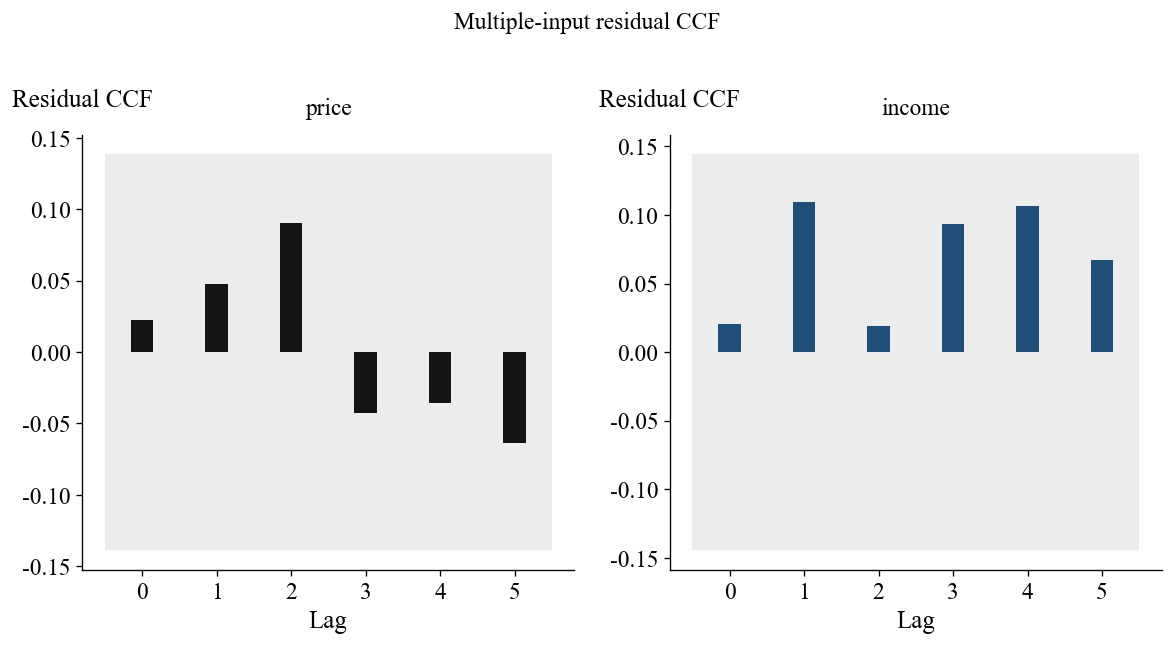

Price input significant lags: ()


In [5]:
fig, axes = multi_result.plot_test(title="Multiple-input residual CCF")
show_figure(fig)
plt.close(fig)

# 也可以只查看某一个输入。
price_item = multi_result.get("price")
print("Price input significant lags:", price_item.significant_lags)

## 3. RDL/SARIMAX integration

RDL 集成入口会自动检查：当前结果是已收敛的 RDL 模型，输入预白化模型拟合到了完全相同的历史输入和日期日历，并且没有额外的 `exog`、事件、RDL 或隐藏的对数变换。

In [6]:
rng_rdl = np.random.default_rng(42)
x = pd.Series(rng_rdl.normal(size=180), name="x")
y = 0.8 * x.to_numpy() + rng_rdl.normal(scale=0.3, size=180)

fitted_rdl = SARIMAX(
    y,
    exog=x,
    trend="n",
    distributed_lags={"x": RationalLagSpec()},
).fit(method="bfgs", maxiter=300, require_convergence=True)

input_model = SARIMAX(x, trend="n").fit()
rdl_result = fitted_rdl.residual_ccf_test(
    {"x": input_model},
    lags=6,
)

rdl_item = rdl_result.get("x")
print("RDL converged:", fitted_rdl.converged)
print("Input names:", rdl_result.input_names)
print("Active transfer parameters:", rdl_item.transfer_params)
display(rdl_result.tests.round(4))

RDL converged: True
Input names: ('x',)
Active transfer parameters: 1


,input,s_statistic,df,p_value,reject,nobs,transfer_params
0,x,2.7344,6,0.8414,False,180,1


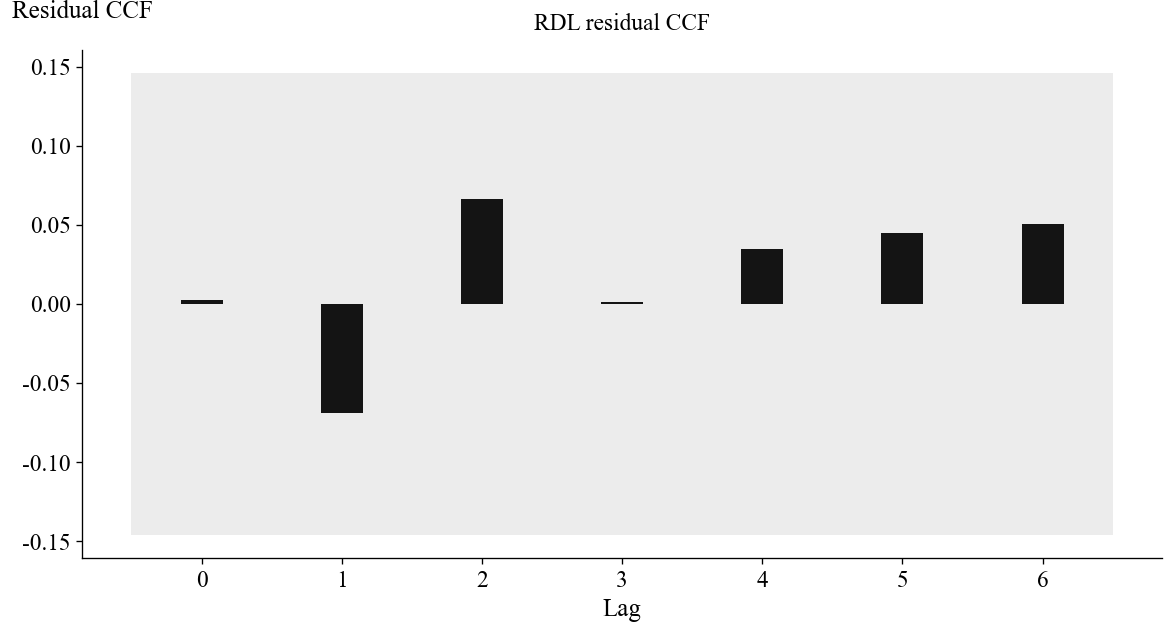

In [7]:
fig, ax = rdl_result.plot_test(inputs="x", title="RDL residual CCF")
show_figure(fig)
plt.close(fig)

对 `RationalLagSpec()`，当前默认规格有 1 个活动传递函数参数。因此本例 `lags=6` 时，联合检验自由度为 `6 + 1 - 1 = 6`。输入 ARIMA 模型的参数不计入这个自由度。

## 4. Precomputed plotting

`plot_correlogram()` 只负责绘制已经计算好的相关系数和置信带，不重新计算 CCF。

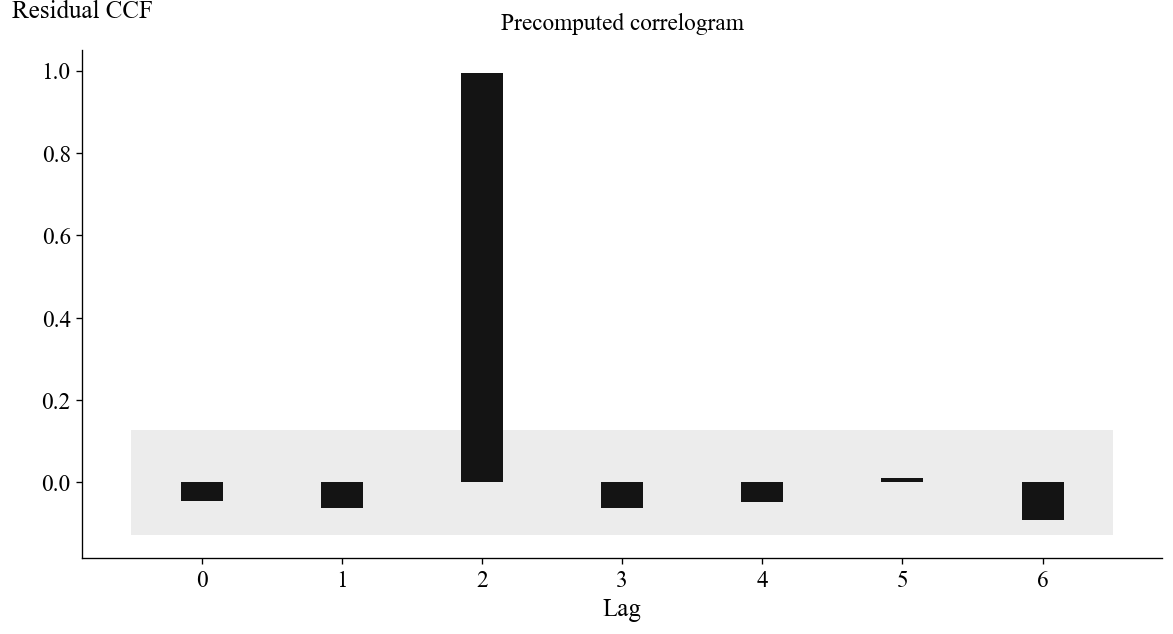

In [8]:
fig, ax = plot_correlogram(
    direct_item.correlations,
    confidence_band=direct_item.confidence_limits["upper"],
    title="Precomputed correlogram",
    ytitle="Residual CCF",
)
show_figure(fig)
plt.close(fig)

## Checks

下面的检查把本 Notebook 中的关键结果变成可重复的断言，并演示一个预期的输入校验错误。

In [9]:
assert direct_result.input_names == ("shock",)
assert direct_item.correlations.index.tolist() == list(range(7))
assert 2 in direct_item.significant_lags
assert multi_result.get("income").nobs == 185
assert rdl_item.transfer_params == 1
assert rdl_item.df == 6

try:
    ResidualCCFTest(np.ones(30), np.arange(30.0), lags=3)
except ValueError as error:
    expected_error = str(error)
else:
    raise AssertionError("Constant residuals should be rejected")

checks = pd.DataFrame(
    {
        "check": [
            "Known lag 2 is detected",
            "Shorter input is right-aligned",
            "RDL parameter count is active-only",
            "Constant residuals are rejected",
        ],
        "status": ["PASS"] * 4,
    }
)
display(checks)
print("Expected validation error:", expected_error)

,check,status
0,Known lag 2 is detected,PASS
1,Shorter input is right-aligned,PASS
2,RDL parameter count is active-only,PASS
3,Constant residuals are rejected,PASS


Expected validation error: output residuals must vary over the aligned sample


## Takeaways

- 在固定模拟数据中，已知的 2 期输入动态在残差 CCF 中表现为 `lag=2` 的显著峰值。
- 多输入结果会分别保存 `nobs`、`S*`、自由度、p 值和显著滞后；结果级 `nobs` 取各输入有效样本数的最小值。
- RDL 集成不会自动生成输入预白化模型；预白化模型必须显式传入，并且必须使用相同的输入数据、日历和尺度。
- CCF 峰值是模型充分性诊断线索，不是自动增加传递函数阶数的命令，也不等于结构因果关系。

## Next Steps

在实际项目中，建议把本 Notebook 中的模拟 `output_residuals` 和 `input_innovations` 替换为已拟合模型的真实残差与输入新息，并同时检查残差白噪声、反馈、输入相关性和样本外预测表现。